# 2D Euler-Bernoulli Beam



In [1]:
# [collapse: code] Colab Setup (Install Dependencies)

# Only run this if we are in Google Colab
if 'google.colab' in str(get_ipython()):
    print("Installing dependencies using uv...")
    # Install uv if not available
    !pip install -q uv
    # Install system dependencies
    !apt-get install -qq gmsh
    # Use uv to install Python dependencies
    !uv pip install --system matplotlib meshio
    !uv pip install --system "git+https://github.com/smec-ethz/tatva-docs.git"
    print("Installation complete!")
    


This tutorial demonstrates how to implement a custom **Euler-Bernoulli Beam** element using `tatva`.

In traditional Finite Element Analysis (FEA), you often choose from a library of pre-existing elements. If you need a specific formulation that isn't in the library, you are stuck.

`tatva` works differently. You define the physics (energy density) and the kinematics (how nodes move), and the engine handles the complex calculus for you. This allows you to create your own elements from scratch without manually deriving stiffness matrices.

In this example, we build a beam element that requires $C^1$ continuity (smooth slope). We define our own **Hermite interpolation** and use JAX's Automatic Differentiation (AD) to compute curvatures and strains.

## Setup and Imports

We start by configuring JAX. Finite Element Method (FEM) calculations usually require double precision (`float64`) to ensure the stiffness matrix is accurate. We also import `tatva` components to handle the mesh and operator logic.

In [1]:
import jax


import time
from typing import NamedTuple, Tuple

import jax.experimental.sparse as jsp
import jax.numpy as jnp
import numpy as np
from jax import Array
from jax_autovmap import autovmap
from tatva import Mesh, Operator, element, sparse

jax.config.update("jax_enable_x64", True)  # use double-precision


## Mesh Generation

We create a simple 1D line mesh embedded in 2D space. The `Mesh` object in `tatva` holds two key pieces of data:

-  **Coordinates**: Where the nodes are located in space.
-  **Connectivity**: Which nodes connect to form an element.

In [2]:
# [collapse: code] Mesh creation function

def create_beam_structure(nb_elem, length=1):
    xi = jnp.linspace(0, length, nb_elem + 1)
    yi = jnp.zeros_like(xi)
    coordinates = jnp.vstack((xi.flatten(), yi.flatten())).T
    connectivity = list()
    for i in range(nb_elem):
        connectivity.append([i, i + 1])
    connectivity = jnp.unique(jnp.array(connectivity), axis=0)

    mesh = Mesh(coords=coordinates, elements=connectivity)

    return mesh

In [3]:
L = 10  # Total length of the beam
nb_elem = 20

mesh = create_beam_structure(nb_elem=nb_elem, length=L)
n_nodes = mesh.coords.shape[0]
nb_nodes_per_cell = mesh.elements.shape[1]
nb_dofs_per_node = 3
n_dofs = n_nodes * nb_dofs_per_node

## Defining Custom Hermite Beam Element

This is the core of the implementation. The Euler-Bernoulli beam theory assumes that plane sections remain plane and perpendicular to the neutral axis. This implies zero shear deformation.

To satisfy this, the displacement field $w(x)$ must have a continuous first derivative (slope). Standard linear or quadratic elements cannot provide this. We must use **Cubic Hermite Splines**.

We define a custom element class `HermiteBeamElement2D` that inherits from `tatva.element.Element`.

**Key features of this implementation:**

* **Custom Interpolation**: We override the `interpolate` method to use Hermite basis functions.
* **Automatic Derivatives**: We do not derive the $B$-matrix manually. We use `jax.grad` to compute the rotation ($\theta = w'$) and curvature ($\kappa = w''$) directly from the shape functions.
* **Local Coordinates**: We implement a helper `_get_local_dofs` to rotate global displacements into the element's local frame.


!!! info "Defining Custom Element"

    To define a custom element inherit from `tatva.element.Element` and reimplement the following functions:

    - `shape_function`
    - `shape_function_derivative`
    - `gradient` which is used by `Operator.grad` to compute the gradient of physical   field
    - `interpolate` If we do not implement interpolate function that the `Operator`     class will use the default `interpolate` which uses `shape_functions` to compute the quadrature values  

    Here we overwrote `interpolate` as hermite shape function also use coordinate values to interpolate.

In [10]:
# [collapse: code] Hermite Interpolator and Beam Element Class

class HermiteInterpolator2D:
    """
    Utility class for Cubic Hermite Spline interpolation in 2D.
    """

    @staticmethod
    def _hermite_basis(xi: Array, L: float) -> Array:
        """Returns the Hermite basis functions for a given x and element length L."""
        H1 = (2 + xi) * (1 - xi) ** 2 / 4
        H2 = L * (1 + xi) * (1 - xi) ** 2 / 8
        H3 = (2 - xi) * (1 + xi) ** 2 / 4
        H4 = L * (1 + xi) ** 2 * (xi - 1) / 8
        return jnp.array([H1, H2, H3, H4])

    @staticmethod
    def axial_displacement(xi, u1, u2):
        """Linear interpolation for axial displacement."""
        return 0.5 * (1 - xi) * u1 + 0.5 * (1 + xi) * u2

    @staticmethod
    def transverse_displacement(xi, w1, theta1, w2, theta2, L):
        """Cubic interpolation for transverse displacement w(x)."""
        H = HermiteInterpolator2D._hermite_basis(xi, L)
        return H[0] * w1 + H[1] * theta1 + H[2] * w2 + H[3] * theta2

    @staticmethod
    def axial_strain(xi, u1, u2, L):
        """Derivative of axial displacement."""
        du_dxi = jax.grad(HermiteInterpolator2D.axial_displacement, argnums=0)
        return du_dxi(xi, u1, u2) * (2 / L)  # Chain rule for d/dx

    @staticmethod
    def transverse_gradient(xi, w1, theta1, w2, theta2, L):
        """First derivative of transverse displacement (Slope). Automatically derived via AD."""
        dw_dxi = jax.grad(HermiteInterpolator2D.transverse_displacement, argnums=0)
        return dw_dxi(xi, w1, theta1, w2, theta2, L) * (2 / L)  # Chain rule for d/dx

    @staticmethod
    def rotation(xi, w1, theta1, w2, theta2, L):
        """First derivative of transverse displacement (Slope). Automatically derived via AD."""
        dw_dxi = jax.grad(HermiteInterpolator2D.transverse_displacement, argnums=0)
        return dw_dxi(xi, w1, theta1, w2, theta2, L)

    @staticmethod
    def curvature(xi, w1, theta1, w2, theta2, L):
        """Second derivative of transverse displacement. Automatically derived via AD."""
        d2w_dxi2 = jax.grad(HermiteInterpolator2D.rotation, argnums=0)
        return (
            d2w_dxi2(xi, w1, theta1, w2, theta2, L) * (2 / L) ** 2
        )  # Chain rule for d^2/dx^2


class HermiteBeamElement2D(element.Element):
    """
    2-node Hermite beam element (Euler-Bernoulli) in 2D for small deformations.
    - DoFs per node: [u, w, theta]
    - Strains: [axial_strain, shear=0, curvature]

    By default, this element uses 3-point Gauss-Legendre quadrature for integration, but this
    can be overridden by passing custom quadrature points and weights to the constructor.
    """

    dofs_per_node: int = 3

    def _default_quadrature(self):
        pts, wts = np.polynomial.legendre.leggauss(3)
        quad_points, quad_weights = jnp.array(pts), jnp.array(wts)
        return quad_points, quad_weights

    def _reference_nodes(self):
        return jnp.array([[-1.0, 0.0], [1.0, 0.0]])


    def shape_function(self, xi: Array) -> Array:
        raise NotImplementedError(
            "Shape function is not defined for hermite beam. Use local interpolation instead."
        )

    def shape_function_derivative(self, xi: Array) -> Array:
        raise NotImplementedError(
            "Shape function derivative is not defined for hermite beam. Use local interpolation instead."
        )

    def interpolate(
        self,
        xi: Array,
        nodal_values: Array,
        nodal_coords: Array,
    ) -> Array:
        L = self.compute_length(nodal_coords)
        u1, w1, th1, u2, w2, th2 = self._get_local_dofs(nodal_values, nodal_coords)

        u_val = HermiteInterpolator2D.axial_displacement(xi, u1, u2)
        w_val = HermiteInterpolator2D.transverse_displacement(xi, w1, th1, w2, th2, L)
        theta_val = HermiteInterpolator2D.rotation(xi, w1, th1, w2, th2, L)

        return jnp.array([u_val, w_val, theta_val])

    def compute_length(self, coords: Array) -> float:
        return jnp.linalg.norm(coords[1] - coords[0])

    def get_jacobian(self, xi: Array, nodal_coords: Array) -> Tuple[Array, Array]:
        L = self.compute_length(nodal_coords)
        detJ = L / 2.0
        return detJ, detJ

    def _get_local_dofs(self, dofs: Array, coords: Array) -> Array:
        """
        Compute the dofs of the beam in the local frame.
        """
        dx = coords[1, 0] - coords[0, 0]
        dy = coords[1, 1] - coords[0, 1]
        L = jnp.sqrt(dx**2 + dy**2)

        cos_theta = dx / L
        sin_theta = dy / L

        # Transformation matrix for each node
        T_node = jnp.array(
            [[cos_theta, sin_theta, 0], [-sin_theta, cos_theta, 0], [0, 0, 1]]
        )

        # Transform DOFs for both nodes
        dofs_local_1 = T_node @ dofs[0]
        dofs_local_2 = T_node @ dofs[1]

        # Return as [u1, w1, theta1, u2, w2, theta2]
        return jnp.array(
            [
                dofs_local_1[0],
                dofs_local_1[1],
                dofs_local_1[2],
                dofs_local_2[0],
                dofs_local_2[1],
                dofs_local_2[2],
            ]
        )

    def gradient(self, xi: Array, nodal_values: Array, nodal_coords: Array) -> Array:
        """
        Computes the generalized strain vector.
        Returns shape (1, 3): [Axial Strain, Shear Strain, Curvature]
        """
        L = self.compute_length(nodal_coords)

        u1, w1, th1, u2, w2, th2 = self._get_local_dofs(nodal_values, nodal_coords)

        axial = HermiteInterpolator2D.axial_strain(xi, u1, u2, L)
        curvature = HermiteInterpolator2D.curvature(xi, w1, th1, w2, th2, L)

        # Euler-Bernoulli assumption: Shear is identically zero
        shear = HermiteInterpolator2D.transverse_gradient(xi, w1, th1, w2, th2, L)

        return jnp.array([axial, shear, curvature])


## Strain Energy Density

We define the material behavior. For a linear elastic Euler-Bernoulli beam, the potential energy density $\Psi$ depends on the axial strain $\varepsilon$ and the curvature $\kappa$:

$$\Psi(\varepsilon, \kappa) = \frac{1}{2} EA \varepsilon^2 + \frac{1}{2} EI \kappa^2$$

We use the `@autovmap` decorator. This tells JAX to automatically vectorize this function, applying it efficiently to every integration point in the mesh at once.

In [11]:
@autovmap(grad_z=1, E=0, A=0, I=0)
def euler_bernoulli_density(grad_z, E, A, I):
    """
    Computes strain energy density at a single integration point.

    Args:
        grad_z: (3,) Gradient of displacement and rotation w.r.t arc length s
        E, A, I: Scalar stiffness properties
    Returns:
        Scalar energy density
    """

    axial, shear, curvature = grad_z

    w_axial = 0.5 * E * A * axial**2
    w_bend = 0.5 * E * I * curvature**2

    return w_axial + w_bend

## Problem Setup: Material and Boundary Conditions

We define the geometric and material properties:
* $E$: Young's Modulus
* $A$: Cross-sectional area
* $I$: Second moment of area

We also define the boundary conditions. We find the node indices for the left and right ends of the beam. We clamp the left end (fixing displacements and rotation) and apply a load to the right end.

In [12]:
# material and geometrical parameters
E = 500
h = 1
A = h**2
I = h * h**3 / 12



class Material(NamedTuple):
    E: float
    A: float
    I: float


mat = Material(E=E, A=A, I=I)

In [13]:
x_max = jnp.max(mesh.coords[:, 0])
x_min = jnp.min(mesh.coords[:, 0])
y_max = jnp.max(mesh.coords[:, 1])
y_min = jnp.min(mesh.coords[:, 1])

left_nodes = jnp.where(jnp.isclose(mesh.coords[:, 0], x_min, atol=1e-6))[0]

right_nodes = jnp.where(jnp.isclose(mesh.coords[:, 0], x_max, atol=1e-6))[0]


fixed_dofs = jnp.concatenate(
    [
        left_nodes * nb_dofs_per_node,
        left_nodes * nb_dofs_per_node + 1,
        left_nodes * nb_dofs_per_node + 2,
    ]
)

applied_dofs = jnp.array(right_nodes * nb_dofs_per_node + 1)

free_dofs = jnp.setdiff1d(jnp.arange(n_dofs), fixed_dofs)

## The `Operator` and Energy Minimization

We initialize the `Operator` with our mesh and custom element. This binds the geometry to the physics. We then define the `total_energy` function. This function integrates the energy density over the entire domain.

* **Input**: Global displacement vector.
* **Output**: Total scalar energy.

Because `tatva` is a differentiable engine, we can compute the internal force vector simply by taking the gradient of this energy function: $\boldsymbol{f}_{int} = \nabla \Psi$.

In [14]:
beam_element = HermiteBeamElement2D()
op = Operator(mesh=mesh, element=beam_element)

In [15]:
@jax.jit
def total_energy(z_flat: Array) -> Array:
    """
    Computes total Euler-Bernoulli beam energy.
    Args:
        z_flat: (n_nodes * 3,) Flattened displacement and rotation vector (ux1, uy1, theta1, ...)
        tangents: (n_elements, 3) Unit tangent vectors for each element
    Returns:
        Scalar total energy of the beam
    """

    z = z_flat.reshape(-1, 3)  # ux, uy, theta

    grad_z = op.grad(z)

    density = euler_bernoulli_density(grad_z, mat.E, mat.A, mat.I)

    return op.integrate(density)

## Applying Boundary Conditions to the Energy Functional

To solve the system, we must distinguish between **free DOFs** (nodes that can move) and **fixed DOFs** (nodes with prescribed displacements). We apply these constraints directly within the energy functional. The total energy of the system depends on the full displacement vector $u_{full}$. However, the optimizer only needs to find the values for the free DOFs. We create a wrapper function that takes only the unknown values (`u_free`) and the prescribed values (`applied_disp`) as inputs.

Inside the wrapper, we reconstruct the complete displacement vector. We use JAX's functional array updates (`at[].set()`) to ensure the operation is compatible with automatic differentiation.

In [16]:
@jax.jit
def total_energy_free(u_free, applied_disp):
    u_full = jnp.zeros(n_dofs).at[free_dofs].set(u_free)
    u_full = u_full.at[fixed_dofs].set(applied_disp)
    return total_energy(u_full)


compute_internal_free = jax.jacrev(total_energy_free)

## Sparse Solver

To solve the system, we minimize the total potential energy. We use a Newton-Raphson scheme, which is robust for both linear and nonlinear problems.

1.  **Sparsity**: We compute the sparsity pattern of the Hessian (stiffness matrix) and color the graph. This allows AD to compute the matrix efficiently.
2.  **Solver Loop**:
    
    * Compute Residual: $\boldsymbol{r} = \boldsymbol{f}_{ext} - \boldsymbol{f}_{int}$
    * Compute Stiffness: $K = \nabla^2 \Psi$ 
    * Solve linear system: $K \Delta \boldsymbol{u} = -\boldsymbol{r}$
    * Update solution.

In [17]:
sparsity_pattern_csr = sparse.create_sparsity_pattern(
    mesh, n_dofs_per_node=nb_dofs_per_node
)
reduced_sparsity_pattern_csr = sparse.reduce_sparsity_pattern(
    sparsity_pattern_csr, free_dofs
)
colored_matrix = sparse.ColoredMatrix.from_csr(reduced_sparsity_pattern_csr)

### Sparse solver with implicit condensation

In [18]:
def fn(u, fext, applied_disp):
    fint = compute_internal_free(u, applied_disp)
    return fext - fint


In [19]:
u = jnp.zeros(n_dofs)
fext = jnp.zeros(n_dofs)

nsteps = 20
P = -1.0
applied_loading = jnp.linspace(0, P, num=nsteps)


u_free = u.at[free_dofs].get()

start_time = time.time()
hessian_fn = sparse.jacfwd(
    fn=fn,
    colored_matrix=colored_matrix,
    color_batch_size=len(jnp.unique(colored_matrix.colors)) + 1,
)
hessian_fn = jax.jit(hessian_fn)

print(f"Time to compute Hessian: {time.time() - start_time:.2f} seconds")

max_iter = 20

for step, load in enumerate(applied_loading):
    fext = fext.at[applied_dofs].set(load)
    fext_free = fext.at[free_dofs].get()

    def fn_partial(u_free):
        return fn(u_free, fext_free, applied_disp=jnp.zeros(len(fixed_dofs)))

    def hessian_partial(u_free):
        return hessian_fn(u_free, fext_free, applied_disp=jnp.zeros(len(fixed_dofs)))

    residual = fn_partial(u_free)
    K_sparse = hessian_partial(u_free)

    du = jnp.zeros(len(free_dofs))
    rnorm = jnp.linalg.norm(residual)
    iiter = 0

    while rnorm > 1e-8 and iiter < max_iter:
        start_time = time.time()
        du = du + jsp.linalg.spsolve(
            K_sparse.data,
            indices=K_sparse.indices,
            indptr=K_sparse.indptr,
            b=-residual,
        )

        u_curr = u_free + du
        residual = fn_partial(u_curr)

        K_sparse = hessian_partial(u_curr)

        rnorm = jnp.linalg.norm(residual)

        iiter += 1

    u_free = u_free + du
    u = u.at[free_dofs].set(u_free)

    print(load, rnorm)

Time to compute Hessian: 0.32 seconds
0.0 0.0
-0.05263157894736842 1.0226066339679528e-12
-0.10526315789473684 2.1290628763345342e-12
-0.15789473684210525 1.9474385273603595e-12
-0.21052631578947367 3.4888731207826387e-12
-0.2631578947368421 3.022618085139983e-12
-0.3157894736842105 5.6798480284671376e-12
-0.3684210526315789 7.383846594835723e-12
-0.42105263157894735 1.0005639702457447e-11
-0.47368421052631576 7.077797707204222e-12
-0.5263157894736842 5.510784592556764e-12
-0.5789473684210527 5.875491716283076e-12
-0.631578947368421 1.3935937312869008e-11
-0.6842105263157894 2.2498072400411463e-11
-0.7368421052631579 1.174453419321761e-11
-0.7894736842105263 1.5067711136635974e-11
-0.8421052631578947 9.286443300382963e-12
-0.894736842105263 2.031778437689385e-11
-0.9473684210526315 2.162285292517473e-11
-1.0 1.7639380869434547e-11


## Validation

We compare the Finite Element results against the analytical solution for a cantilever beam with a point load $P$ at the tip.

**Analytical Solutions:**

* Deflection: 

$$w(x) = \frac{P x^2}{6EI} (3L - x)$$

* Rotation: 

$$\theta(x) = \frac{P x}{2EI} (2L - x)$$

The plots below show that our custom `tatva` element matches the theoretical values.

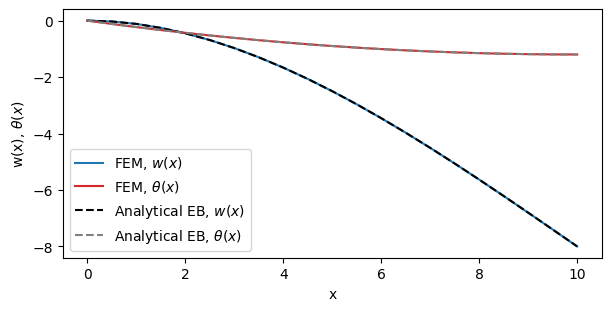

In [20]:
# [collapse: code] Plotting the results


import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6, 3), constrained_layout=True)
ax = plt.axes()

ax.plot(
    mesh.coords[:, 0],
    u.reshape((n_nodes, nb_dofs_per_node))[:, 1],
    color="tab:blue",
    label="FEM, $w(x)$",
)
ax.plot(
    mesh.coords[:, 0],
    u.reshape((n_nodes, nb_dofs_per_node))[:, 2],
    color="tab:red",
    label="FEM, $\\theta(x)$",
)


ax.plot(
    mesh.coords[:, 0],
    P * (3 * L * mesh.coords[:, 0] ** 2 - mesh.coords[:, 0] ** 3) / (6 * E * I),
    color="k",
    ls="dashed",
    label="Analytical EB, $w(x)$",
)
ax.plot(
    mesh.coords[:, 0],
    P * (2 * L * mesh.coords[:, 0] - mesh.coords[:, 0] ** 2) / (2 * E * I),
    color="gray",
    ls="dashed",
    label="Analytical EB, $\\theta(x)$",
)

# ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("w(x), $\\theta(x)$")
ax.legend()
plt.show()